<a href="https://colab.research.google.com/github/orutkina/-./blob/main/44.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание 4

In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()


Saving archive.zip to archive.zip


In [2]:
df = pd.read_csv(list(uploaded.keys())[0])
df.head()


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [3]:
df.columns


Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

In [4]:
df = df.drop(columns=['Person ID'])


In [5]:
df.isnull().sum()


,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0
Heart Rate,0


In [6]:
# числовые столбцы
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# категориальные столбцы
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


На данном этапе были удалены неинформативные признаки и обработаны пропущенные значения.
Числовые признаки были заполнены медианными значениями, а категориальные — наиболее
часто встречающимися значениями.


In [7]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, drop='first')

X_cat = encoder.fit_transform(df[cat_cols])

X_cat = pd.DataFrame(
    X_cat,
    columns=encoder.get_feature_names_out(cat_cols)
)


In [8]:
X_num = df[num_cols].reset_index(drop=True)
X_cat = X_cat.reset_index(drop=True)

X = pd.concat([X_num, X_cat], axis=1)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Категориальные признаки были закодированы с помощью One-Hot Encoding.
После этого все признаки были масштабированы с использованием StandardScaler,
чтобы привести их к одному масштабу перед выполнением кластеризации.


In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


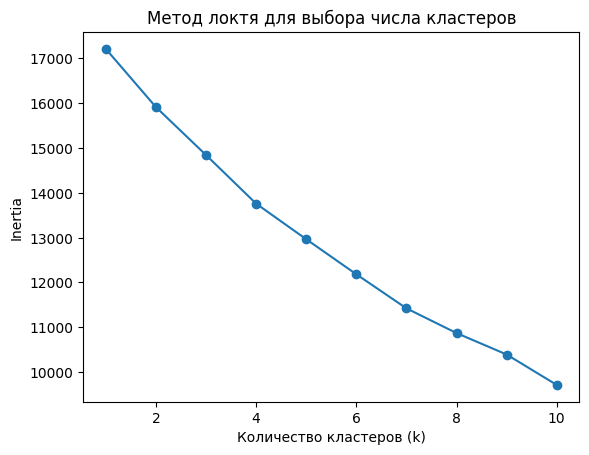

In [11]:
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Количество кластеров (k)")
plt.ylabel("Inertia")
plt.title("Метод локтя для выбора числа кластеров")
plt.show()


Для выбора оптимального числа кластеров был использован метод локтя.
По графику зависимости inertia от количества кластеров было выбрано
значение k, соответствующее точке излома кривой.


In [12]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)


In [13]:
df['Cluster'] = clusters
df.head()


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Cluster
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,Sleep Apnea,0
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,Sleep Apnea,1
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,Sleep Apnea,1
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,0
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,0


На основе метода локтя было выбрано количество кластеров k = 3.
Далее была обучена модель KMeans, и каждому объекту был присвоен номер кластера.


In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


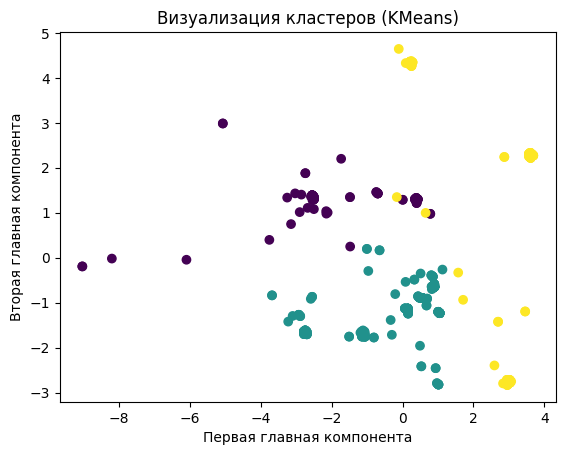

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.xlabel("Первая главная компонента")
plt.ylabel("Вторая главная компонента")
plt.title("Визуализация кластеров (KMeans)")
plt.show()


Для визуализации результатов кластеризации было применено снижение размерности
с помощью метода PCA до двух главных компонент. На графике видно, что объекты
разбиваются на три группы, соответствующие найденным кластерам.


В данной лабораторной работе была выполнена кластеризация данных о сне и образе жизни людей
с использованием алгоритма KMeans. На этапе предобработки данные были очищены, категориальные
признаки закодированы, а все признаки масштабированы.

Для выбора оптимального числа кластеров был применён метод локтя, по которому было выбрано
k = 3. После обучения модели каждому объекту был присвоен номер кластера.

Для наглядного представления результатов была использована визуализация с помощью метода PCA.
Полученные кластеры показывают, что данные можно разделить на несколько групп людей с похожими
характеристиками образа жизни и сна.
